# Fleiss Kappa – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/fleiss-kappa)

Das **Fleiss Kappa (κ)** misst die Inter-Rater-Reliabilität bei **3 oder mehr Ratern**
mit **nominalen Daten**.

**Formel:**
$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

**Berechnung von $p_o$ und $p_e$:**

$$p_o = \frac{1}{N \cdot n(n-1)} \left(\sum_i \sum_k n_{ik}^2 - Nn\right)$$

$$p_e = \sum_k p_k^2, \quad p_k = \frac{\sum_i n_{ik}}{N \cdot n}$$

| Symbol | Bedeutung |
|---|---|
| $N$ | Anzahl Objekte/Patienten |
| $n$ | Anzahl Rater |
| $n_{ik}$ | Anzahl Rater, die Objekt $i$ in Kategorie $k$ einordnen |
| $p_k$ | Anteil aller Ratings der Kategorie $k$ |

**Interpretation (Landis & Koch 1977):** Gleich wie Cohens Kappa

**Überblick: Welches Kappa?**

| Rater | Skalenniveau | Methode |
|---|---|---|
| 2 | Nominal | Cohens Kappa |
| 2 | Ordinal | Gewichtetes Cohens Kappa |
| **3+** | **Nominal** | **Fleiss Kappa** |
| 3+ | Ordinal | Kendalls W |
| 3+ | Metrisch | Intra-Klassen-Korrelation (ICC) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Depressions-Diagnose (N=7, n=3)

Drei Ärzte bewerten 7 Patienten: **depressiv (1)** oder **nicht depressiv (0)**

**Datentabelle (numiqo):**

| Patient | Rater1 | Rater2 | Rater3 | #nicht-dep. | #dep. |
|---|---|---|---|---|---|
| 1 | dep | dep | dep | 0 | 3 |
| 2 | nicht | dep | dep | 1 | 2 |
| 3 | nicht | nicht | dep | 2 | 1 |
| 4 | nicht | nicht | nicht | 3 | 0 |
| 5 | dep | dep | nicht | 1 | 2 |
| 6 | dep | dep | dep | 0 | 3 |
| 7 | nicht | dep | dep | 1 | 2 |

**Erwartetes numiqo-Ergebnis:** κ = 0,19 → geringe Übereinstimmung

In [2]:
# numiqo-Datensatz: 7 Patienten, 3 Rater, 2 Kategorien (0=nicht dep., 1=dep.)
N = 7   # Patienten
n = 3   # Rater
k = 2   # Kategorien

# Ratings: Zeilen=Patienten, Spalten=Rater
ratings = np.array([
    [1, 1, 1],  # P1: alle dep
    [0, 1, 1],  # P2: 1 nicht dep, 2 dep
    [0, 0, 1],  # P3: 2 nicht dep, 1 dep
    [0, 0, 0],  # P4: alle nicht dep
    [1, 1, 0],  # P5: 2 dep, 1 nicht dep
    [1, 1, 1],  # P6: alle dep
    [0, 1, 1],  # P7: 1 nicht dep, 2 dep
], dtype=int)

# n_ik: wie viele Rater ordnen Patient i in Kategorie k ein
n_ik = np.column_stack([
    (ratings == 0).sum(axis=1),   # Kategorie 0: nicht depressiv
    (ratings == 1).sum(axis=1),   # Kategorie 1: depressiv
])

print("Datentabelle")
print("Patient  R1  R2  R3  n_nicht_dep  n_dep")
for i in range(N):
    print(str(i+1) + "        " + str(ratings[i,0]) + "   " +
          str(ratings[i,1]) + "   " + str(ratings[i,2]) +
          "   " + str(n_ik[i,0]) + "            " + str(n_ik[i,1]))
print()

# Summen je Kategorie
sum_k = n_ik.sum(axis=0)
gesamt = N * n
print("Summe nicht-dep: " + str(sum_k[0]) + "  (numiqo: 8)")
print("Summe dep:       " + str(sum_k[1]) + "  (numiqo: 13)")
print("Gesamt Ratings:  " + str(gesamt) + "  (numiqo: 21)")
print()

# p_k: Anteil je Kategorie
p_k = sum_k / gesamt
print("p(nicht-dep) = " + str(sum_k[0]) + "/" + str(gesamt) +
      " = " + str(round(p_k[0], 4)) + "  (numiqo: 0.38)")
print("p(dep)       = " + str(sum_k[1]) + "/" + str(gesamt) +
      " = " + str(round(p_k[1], 4)) + "  (numiqo: 0.62)")
print()

# pe: erwartete Übereinstimmung
pe = (p_k**2).sum()
print("pe = " + str(round(p_k[0],4)) + "^2 + " + str(round(p_k[1],4)) + "^2 = " +
      str(round(pe, 4)) + "  (numiqo: 0.53)")
print()

# po: beobachtete Übereinstimmung
sum_n2 = (n_ik**2).sum()
po = (1 / (N * n * (n-1))) * (sum_n2 - N*n)
print("Sum(n_ik^2) = " + str(int(sum_n2)) + "  (numiqo: 47)")
print("po = 1/(" + str(N) + "*" + str(n) + "*" + str(n-1) + ") * (" +
      str(int(sum_n2)) + " - " + str(N*n) + ")")
print("po = " + str(round(1/(N*n*(n-1)), 4)) + " * " + str(int(sum_n2) - N*n) +
      " = " + str(round(po, 4)) + "  (numiqo: 0.624)")
print()

# Fleiss Kappa
kappa_f = (po - pe) / (1 - pe)
print("Fleiss Kappa")
print("kappa = (" + str(round(po,4)) + " - " + str(round(pe,4)) +
      ") / (1 - " + str(round(pe,4)) + ")")
print("kappa = " + str(round(kappa_f, 4)) + "  (numiqo: 0.19)")
print()

def interpret_kappa(k_v):
    if k_v > 0.8: return "fast perfekt"
    elif k_v > 0.6: return "substanziell"
    elif k_v > 0.4: return "moderat"
    elif k_v > 0.2: return "mäßig"
    elif k_v >= 0: return "gering"
    return "mangelhaft"

print("Interpretation: kappa=" + str(round(kappa_f,3)) +
      " -> " + interpret_kappa(kappa_f))

Datentabelle
Patient  R1  R2  R3  n_nicht_dep  n_dep
1        1   1   1   0            3
2        0   1   1   1            2
3        0   0   1   2            1
4        0   0   0   3            0
5        1   1   0   1            2
6        1   1   1   0            3
7        0   1   1   1            2

Summe nicht-dep: 8  (numiqo: 8)
Summe dep:       13  (numiqo: 13)
Gesamt Ratings:  21  (numiqo: 21)

p(nicht-dep) = 8/21 = 0.381  (numiqo: 0.38)
p(dep)       = 13/21 = 0.619  (numiqo: 0.62)

pe = 0.381^2 + 0.619^2 = 0.5283  (numiqo: 0.53)

Sum(n_ik^2) = 47  (numiqo: 47)
po = 1/(7*3*2) * (47 - 21)
po = 0.0238 * 26 = 0.619  (numiqo: 0.624)

Fleiss Kappa
kappa = (0.619 - 0.5283) / (1 - 0.5283)
kappa = 0.1923  (numiqo: 0.19)

Interpretation: kappa=0.192 -> gering


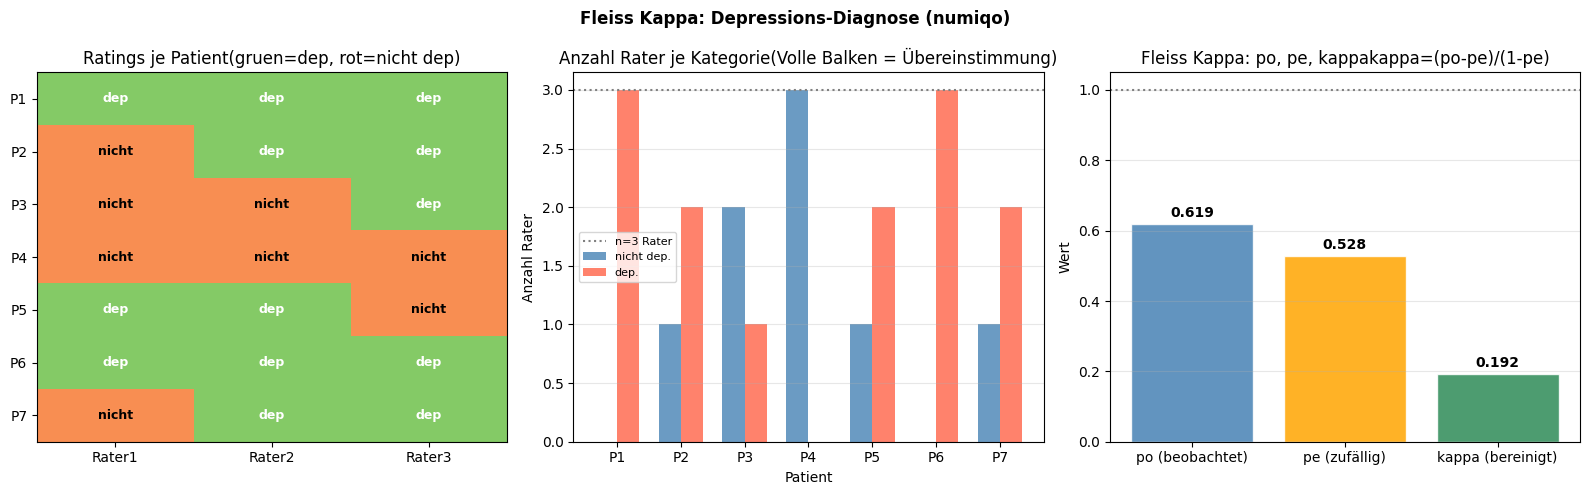

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fleiss Kappa: Depressions-Diagnose (numiqo)", fontsize=12,
             fontweight="bold")

# 1. Ratings-Heatmap
im = axes[0].imshow(ratings, cmap="RdYlGn", vmin=-0.5, vmax=1.5, aspect="auto")
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(N))
axes[0].set_xticklabels(["Rater1", "Rater2", "Rater3"])
axes[0].set_yticklabels(["P" + str(i+1) for i in range(N)])
for i in range(N):
    for j in range(n):
        label = "dep" if ratings[i,j] == 1 else "nicht"
        axes[0].text(j, i, label, ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="white" if ratings[i,j] == 1 else "black")
axes[0].set_title("Ratings je Patient(gruen=dep, rot=nicht dep)")

# 2. n_ik Balken (Übereinstimmungsprofil)
x_pos = np.arange(N)
w = 0.35
bars0 = axes[1].bar(x_pos - w/2, n_ik[:,0], w, color="steelblue", alpha=0.8,
                    label="nicht dep.")
bars1 = axes[1].bar(x_pos + w/2, n_ik[:,1], w, color="tomato", alpha=0.8,
                    label="dep.")
axes[1].axhline(n, color="gray", linestyle=":", linewidth=1.5,
                label="n=3 Rater")
axes[1].set_title("Anzahl Rater je Kategorie(Volle Balken = Übereinstimmung)")
axes[1].set_xlabel("Patient")
axes[1].set_ylabel("Anzahl Rater")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(["P" + str(i+1) for i in range(N)])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

# 3. po vs pe vs kappa
werte = [po, pe, kappa_f]
balken_fc = ["steelblue", "orange", "seagreen"]
namen = ["po (beobachtet)", "pe (zufällig)", "kappa (bereinigt)"]
bars = axes[2].bar(namen, werte, color=balken_fc, edgecolor="white", alpha=0.85)
axes[2].axhline(1, color="gray", linestyle=":", linewidth=1.5)
axes[2].set_title("Fleiss Kappa: po, pe, kappakappa=(po-pe)/(1-pe)")
axes[2].set_ylabel("Wert")
axes[2].set_ylim(0, 1.05)
axes[2].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, werte):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 str(round(val, 3)), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [4]:
# Fleiss Kappa Funktion (manuell, ohne externe Bibliothek)
def fleiss_kappa(ratings_matrix):
    N_f, n_f = ratings_matrix.shape
    kategorien = np.unique(ratings_matrix)
    k_f = len(kategorien)

    n_ik_f = np.zeros((N_f, k_f), dtype=float)
    for ki, kat in enumerate(kategorien):
        n_ik_f[:, ki] = (ratings_matrix == kat).sum(axis=1)

    sum_k_f = n_ik_f.sum(axis=0)
    gesamt_f = N_f * n_f
    p_k_f = sum_k_f / gesamt_f

    pe_f = (p_k_f**2).sum()
    sum_n2_f = (n_ik_f**2).sum()
    po_f = (1 / (N_f * n_f * (n_f - 1))) * (sum_n2_f - N_f * n_f)
    kappa_val = (po_f - pe_f) / (1 - pe_f)
    return kappa_val, po_f, pe_f

# Haupt-Beispiel
kv, pov, pev = fleiss_kappa(ratings)
print("Fleiss Kappa (eigene Funktion)")
print("kappa=" + str(round(kv, 4)) + "  po=" + str(round(pov, 4)) +
      "  pe=" + str(round(pev, 4)))
print("Interpretation: " + interpret_kappa(kv))
print()

# Vergleich: verschiedene Übereinstimmungsniveaus
print("Vergleich: Übereinstimmungsniveaus")
np.random.seed(42)
for beschr, r_mat in [
    ("Hohe Übereinstimmung (kappa~0.8)",
     np.column_stack([np.array([1,1,0,0,1,1,0]*3).reshape(7,3)])),
    ("Mittlere Übereinstimmung (kappa~0.4)",
     np.array([[1,1,0],[1,0,1],[0,0,1],[0,1,0],[1,1,0],[0,1,1],[1,0,0]])),
    ("Niedrige Übereinstimmung (kappa~0.2)",
     ratings),
]:
    kv2, _, _ = fleiss_kappa(r_mat)
    print(beschr + ": kappa=" + str(round(kv2, 3)) +
          " -> " + interpret_kappa(kv2))

Fleiss Kappa (eigene Funktion)
kappa=0.1923  po=0.619  pe=0.5283
Interpretation: gering

Vergleich: Übereinstimmungsniveaus
Hohe Übereinstimmung (kappa~0.8): kappa=-0.361 -> mangelhaft
Mittlere Übereinstimmung (kappa~0.4): kappa=-0.336 -> mangelhaft
Niedrige Übereinstimmung (kappa~0.2): kappa=0.192 -> gering


## 2. Zusammenfassung

```
Fleiss Kappa – Übersicht
│
├── WAS?
│   Inter-Rater-Reliabilitaet für 3+ Rater, nominale Variable
│   Erweiterung von Cohens Kappa auf mehrere Rater
│
├── DATENFORMAT
│   Matrix: N Objekte x n Rater
│   Jede Zelle: Kategorie (nominal)
│
├── BERECHNUNG
│   n_ik = Anzahl Rater, die Objekt i in Kategorie k einordnen
│   p_k  = Anteil aller Ratings in Kategorie k
│   pe   = Sum(p_k^2)  [Zufalls-Übereinstimmung]
│   po   = 1/(N*n*(n-1)) * (Sum(n_ik^2) - N*n)
│   kappa = (po - pe) / (1 - pe)
│
├── INTERPRETATION (Landis & Koch 1977)
│   > 0.8: fast perfekt | > 0.6: substanziell
│   > 0.4: moderat      | > 0.2: maessig
│   0-0.2: gering       | < 0:   mangelhaft
│
├── ÜBERBLICK: WELCHES KAPPA?
│   2 Rater + nominal:   Cohens Kappa
│   2 Rater + ordinal:   Gewichtetes Kappa
│   3+ Rater + nominal:  FLEISS KAPPA
│   3+ Rater + ordinal:  Kendalls W
│   3+ Rater + metrisch: ICC
│
├── numiqo-BEISPIEL: Depression (N=7, n=3)
│   po=0.624, pe=0.53, kappa=0.19 -> gering
│
└── PYTHON (manuell, ohne externe Bibliothek)
    def fleiss_kappa(ratings_matrix):
        # N x n Matrix -> (kappa, po, pe)
        ...
    # Oder: pip install statsmodels
    # from statsmodels.stats.inter_rater import fleiss_kappa
```

---
Quelle: [numiqo.de/tutorial/fleiss-kappa](https://numiqo.de/tutorial/fleiss-kappa)